In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
df = pd.read_csv("../data/cleaned/nassau_featured.csv")

In [4]:
product_summary = df.groupby(
    'Product Name'
).agg({
    'Sales':'sum',
    'Gross Profit': 'sum',
    'Units': 'sum',
    'Gross Margin %': 'mean'
}).reset_index()


In [5]:
#Product Profit Ranking
pareto = product_summary.sort_values(
    'Gross Profit',
    ascending=False
)

In [6]:
#Cumulative Profit %

pareto['Cum Profit %'] = (
    pareto['Gross Profit'].cumsum()
    /
    pareto['Gross Profit'].sum()

)*100

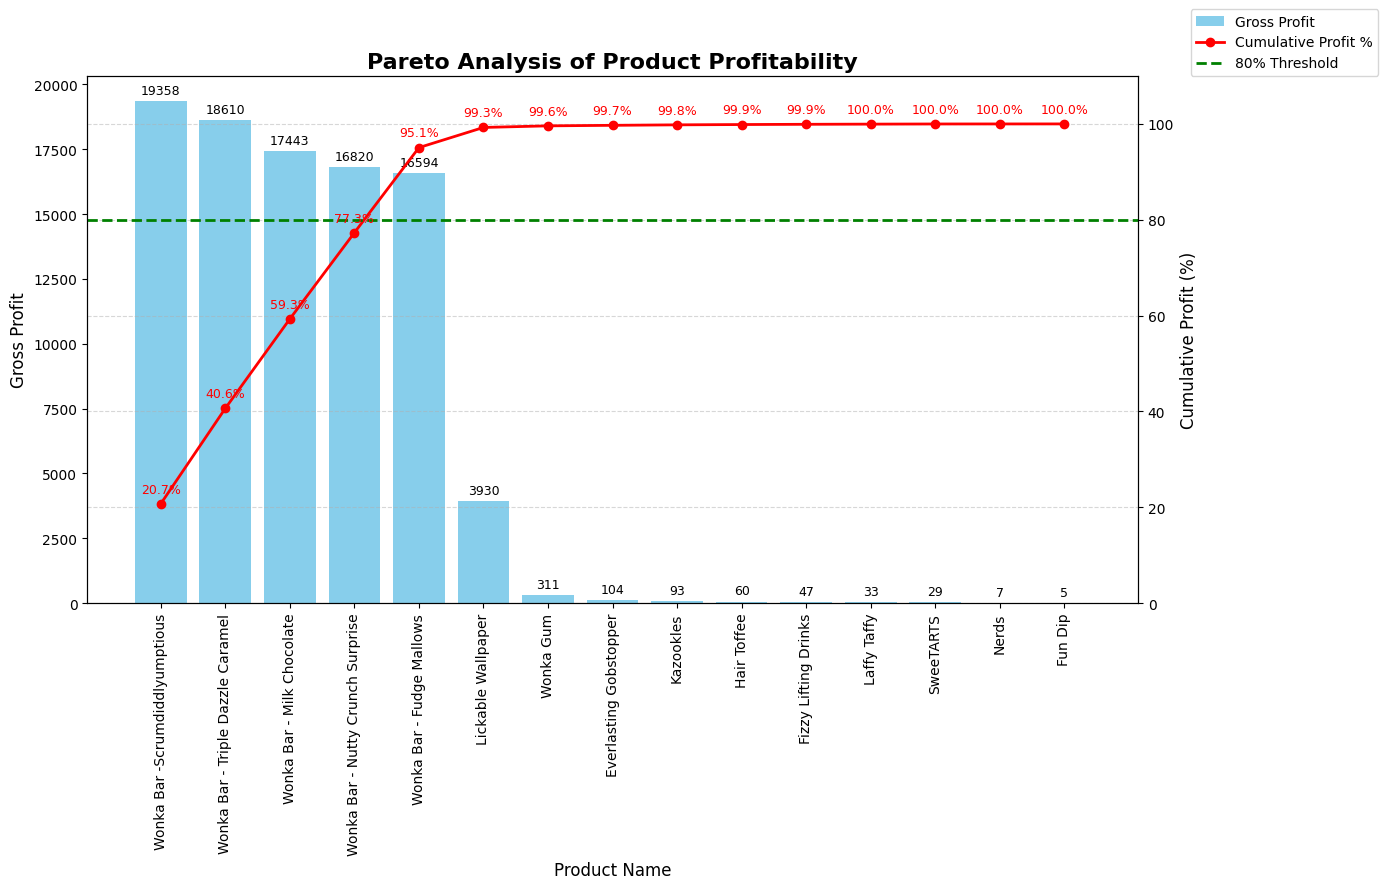

In [7]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14, 9))

bars = ax1.bar(
    pareto['Product Name'],
    pareto['Gross Profit'],
    color='skyblue',
    label='Gross Profit'
)

ax1.bar_label(
    bars,
    fmt='%.0f',         
    padding=3,
    fontsize=9,
    color='black'
)

ax1.set_xlabel("Product Name", fontsize=12)
ax1.set_ylabel("Gross Profit", fontsize=12)
ax1.set_title("Pareto Analysis of Product Profitability", fontsize=16, fontweight='bold')
ax1.tick_params(axis='x', rotation=90)

ax2 = ax1.twinx()

ax2.plot(
    pareto['Product Name'],
    pareto['Cum Profit %'],
    color='red',
    marker='o',
    linewidth=2,
    label='Cumulative Profit %'
)

for x, y in zip(pareto['Product Name'], pareto['Cum Profit %']):
    ax2.annotate(
        f'{y:.1f}%',
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center',
        fontsize=9,
        color='red'
    )

ax2.set_ylabel("Cumulative Profit (%)", fontsize=12)
ax2.set_ylim(0, 110)

ax2.axhline(
    y=80,
    color='green',
    linestyle='--',
    linewidth=2,
    label='80% Threshold'
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left',bbox_to_anchor=(1.05, 1),borderaxespad=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(
    "../visuals/pareto_analysis.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()